In [1]:
import pandas as pd
import numpy as np
from FaceQuant import faceQuant
import os

## Load data

In [2]:
import os

csv_files = []

for root, dirs, files in os.walk('C2shortvideosDLCanalyzed/'):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))



In [3]:
df = pd.read_csv(csv_files[0], header=[1, 2] )
df.columns.names = ["scorer", "bodyparts"]

In [15]:
fq = faceQuant()

quant_df = df.apply(lambda row: fq.get_face_quant(row), axis=1, result_type="expand")
quant_df.columns = [
    "eye_opening",
    "ear_opening",
    "ear_position",
    "snout_position",
    "mouth_position",
    "face_inclination"
]

quant_df['stimuli'] = ['neutral'] * 200 + ['airpuf'] * 100

In [16]:
from scipy.stats import zscore

quant_cols = [
    "eye_opening",
    "ear_opening",
    "ear_position",
    "snout_position",
    "mouth_position",
    "face_inclination"
]

quant_df[quant_cols] = quant_df[quant_cols].apply(zscore)
import numpy as np

mean_df = quant_df.groupby("stimuli")[quant_cols].mean()
sem_df  = quant_df.groupby("stimuli")[quant_cols].sem()



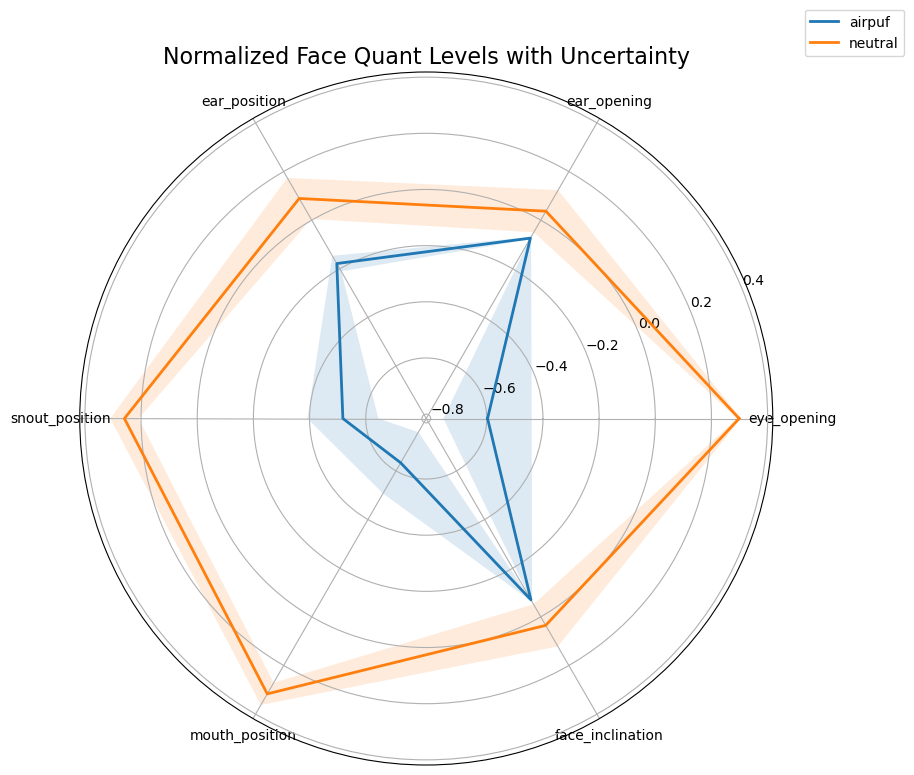

In [17]:
import matplotlib.pyplot as plt
import numpy as np

labels = quant_cols
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for stim in mean_df.index:
    values = mean_df.loc[stim].tolist()
    values += values[:1]

    sem = sem_df.loc[stim].tolist()
    sem += sem[:1]

    lower = np.array(values) - np.array(sem)
    upper = np.array(values) + np.array(sem)

    ax.plot(angles, values, linewidth=2, label=stim)
    ax.fill_between(angles, lower, upper, alpha=0.15)
    
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Normalized Face Quant Levels with Uncertainty", size=16)
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.show()
